In [39]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Download latest version
path = kagglehub.dataset_download("anonymous13635/communities-and-crime-data-set-normalized")

print("Path to dataset files:", path)

Path to dataset files: /home/tanisha/.cache/kagglehub/datasets/anonymous13635/communities-and-crime-data-set-normalized/versions/3


In [40]:
import pandas as pd

# Standard Kaggle path for this specific dataset
df = pd.read_excel(f'{path}/crime_data_normalized.xlsx', na_values='?')

# Quickly drop columns with too many NaNs before PCA
df = df.dropna(axis=1)

/home/tanisha/Documents/MLTP_MCA/MLTP/venv/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [41]:
df.head()

,state,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
0,8,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,0.17,0.34,...,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20
1,53,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,...,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67
2,24,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,0.04,0.39,...,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43
3,34,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,0.10,0.51,...,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12
4,42,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,0.05,0.38,...,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03


In [42]:
df.isnull().sum()

state                  0
communityname          0
fold                   0
population             0
householdsize          0
                      ..
LandArea               0
PopDens                0
PctUsePubTrans         0
LemasPctOfficDrugUn    0
ViolentCrimesPerPop    0
Length: 103, dtype: int64

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 103 entries, state to ViolentCrimesPerPop
dtypes: float64(100), int64(2), object(1)
memory usage: 1.6+ MB


In [44]:
df['state'].value_counts()

state
6     278
34    211
48    156
25    121
39    109
42    101
12     90
9      69
55     60
18     48
36     46
37     46
1      43
29     42
53     40
13     37
40     36
47     35
51     33
41     31
45     28
21     26
44     26
5      25
8      25
49     24
22     22
33     21
4      20
19     20
28     19
23     17
54     14
24     12
35     10
46      9
38      8
16      7
56      7
27      7
32      5
50      4
2       3
20      1
11      1
10      1
Name: count, dtype: int64

In [45]:
df = df.drop(columns='communityname', axis=1)
cat_cols = ['state'] 
num_df = df.select_dtypes(include=[np.number]).dropna(axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)

pca = PCA(n_components=0.90) 
X_pca = pca.fit_transform(X_scaled)

pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=num_df.index)


state_dummies = pd.get_dummies(df[cat_cols])
final_df = pd.concat([pca_df, state_dummies], axis=1)

print(f"Original feature count: {df.shape[1]}")
print(f"Engineered feature count: {final_df.shape[1]}")

Original feature count: 102
Engineered feature count: 25


In [46]:
final_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,state
0,1.330341,-0.869627,-3.305189,-0.913516,1.320567,-3.217971,0.134981,0.232749,-0.457466,-0.200507,...,0.169802,0.036553,0.270972,0.739980,0.087572,-0.299479,0.961350,-0.557156,-0.580271,8
1,-1.676469,0.487502,-4.306162,-2.094668,-2.430881,-4.350949,2.194860,1.985975,0.912326,1.239721,...,-0.349330,-0.413941,0.213921,-1.059627,-0.084395,0.691924,-1.641590,-0.097426,0.418337,53
2,-2.186588,-2.387469,0.139319,0.447027,-0.285925,-2.421485,2.065786,-1.012169,-1.621815,-0.997692,...,-1.948230,0.123534,0.692786,-0.314071,-0.484956,0.208857,0.717202,0.616413,-0.087866,24
3,2.967132,1.960162,3.517156,0.553161,3.187005,-0.309118,4.417780,-2.280907,-2.322009,-3.215499,...,-1.976765,0.546545,1.755762,-1.185074,-0.127789,0.114163,-0.713484,1.459410,-0.301875,34
4,5.665322,-2.706860,2.729345,0.523524,1.769436,-0.477106,-0.712017,0.703105,-0.085280,-0.574647,...,-0.455892,-1.293008,-0.073840,-0.572342,1.037065,0.204109,-0.580469,0.374513,0.278709,42


In [47]:
exp_var_ratio = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var_ratio)

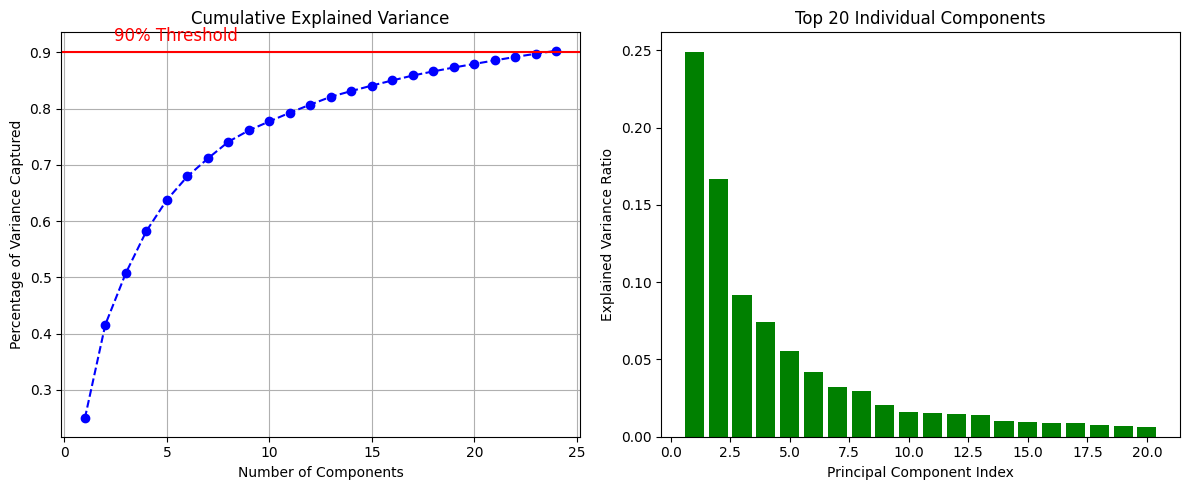

In [48]:
plt.figure(figsize=(12, 5))

# Subplot 1: Cumulative Variance
plt.subplot(1, 2, 1)
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle='-')
# Adjusting text position to be visible on the new smaller scale
plt.text(len(cum_var)*0.1, 0.92, '90% Threshold', color='r', fontsize=12) 
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Percentage of Variance Captured')
plt.grid(True)

# Subplot 2: Individual Variance
plt.subplot(1, 2, 2)
plt.bar(range(1, min(21, len(exp_var_ratio) + 1)), exp_var_ratio[:20], align='center', color='g')
plt.title('Top 20 Individual Components')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')

plt.tight_layout()
plt.show()

In [49]:
k_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Now, we only need {k_90} components out of {X_scaled.shape[1]}")

Now, we only need 24 components out of 102
